# IEEE-CIS Fraud Detection - Exploratory Data Analysis

## Objective
Perform comprehensive exploratory data analysis on our dataset to:
1. Understand data structure and quality
2. Identify fraud patterns and signals
3. Discover feature relationships

# 1. Setup and Imports

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix, precision_recall_curve, roc_curve)
import xgboost as xgb
import warnings
import time
import os

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# 2. Load and merge data

In [40]:
# Load data and merge
train_trans = pd.read_csv('../../data/raw/train_transaction.csv')
train_id = pd.read_csv('../../data/raw/train_identity.csv')

train = train_trans.merge(train_id, on='TransactionID', how='left')
print(f"Transactions with identity: {(~train['DeviceType'].isna()).sum()}")
print(f"Transactions without identity: {train['DeviceType'].isna().sum()}")
identity_rate = (1 - train['DeviceType'].isna().mean()) * 100
print(f"Percentage of transaction with identity: {identity_rate:.2f}%")
print(train.shape)

Transactions with identity: 140810
Transactions without identity: 449730
Percentage of transaction with identity: 23.84%
(590540, 434)


In [42]:
# Save 
train.to_csv('../../data/interim/train.csv', index=False)

# 3. Initial Data Overview

In [3]:
print(train.shape)
print(f"{train.memory_usage(deep=True).sum() / 1024**2}MBs")
print(train.dtypes.value_counts())
print(train.isnull().sum())
display(train.head(3))
display(train.tail(3))

(590540, 434)
2567.094612121582MBs
float64    399
object      31
int64        4
Name: count, dtype: int64
TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
id_36             449555
id_37             449555
id_38             449555
DeviceType        449730
DeviceInfo        471874
Length: 434, dtype: int64


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590539,3577539,0,15811131,279.95,W,15066,170.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Statistical Summary (numeric features)
# Get numeric columns except 
numeric_features = train.select_dtypes(include=['int64', 'float64']).columns.to_list()
numeric_features.remove('TransactionID')
print(len(numeric_features))
summary = train[numeric_features].describe()
display(summary)

402


,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,238269.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,118.502180,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,371.872026,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,0.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,3.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,8.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,24.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,10286.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


In [5]:
# Categorical features
categorical_features = train.select_dtypes(include=['object']).columns.to_list()
print(len(categorical_features))

for col in categorical_features[:15]:
    unique_count = train[col].nunique()
    missing_pct = (train[col].isna().sum() / len(train)) * 100

    print(f"{col:20s}: {unique_count:5d} unique values, {missing_pct:5.1f}% missing")

    if unique_count <= 20 and unique_count > 0:
        top_values = train[col].value_counts().head()
        print(f"Top values: {list(top_values.index)}")

31
ProductCD           :     5 unique values,   0.0% missing
Top values: ['W', 'C', 'R', 'H', 'S']
card4               :     4 unique values,   0.3% missing
Top values: ['visa', 'mastercard', 'american express', 'discover']
card6               :     4 unique values,   0.3% missing
Top values: ['debit', 'credit', 'debit or credit', 'charge card']
P_emaildomain       :    59 unique values,  16.0% missing
R_emaildomain       :    60 unique values,  76.8% missing
M1                  :     2 unique values,  45.9% missing
Top values: ['T', 'F']
M2                  :     2 unique values,  45.9% missing
Top values: ['T', 'F']
M3                  :     2 unique values,  45.9% missing
Top values: ['T', 'F']
M4                  :     3 unique values,  47.7% missing
Top values: ['M0', 'M2', 'M1']
M5                  :     2 unique values,  59.3% missing
Top values: ['F', 'T']
M6                  :     2 unique values,  28.7% missing
Top values: ['F', 'T']
M7                  :     2 unique values,

# 4. Target Variable (isFraud) Analysis
Analyse the distribution of fraud transactions vs legitimate transactions. Is there class imbalance?

In [6]:
# Analyse Fraud Distribution
fraud_count = train['isFraud'].sum()
total_count = len(train)
legitimate = total_count - fraud_count
fraud_rate = (fraud_count / total_count) * 100

print(f"Total transactions: {total_count}")
print(f"Transactions flagged as fraud: {fraud_count}")
print(f"Legitimate transactions: {legitimate}")
print(f"Percentage of transactions that are fraudulent: {fraud_rate:.2f}%")
print(f"Imbalance ratio: {(legitimate / fraud_count):.2f}")

Total transactions: 590540
Transactions flagged as fraud: 20663
Legitimate transactions: 569877
Percentage of transactions that are fraudulent: 3.50%
Imbalance ratio: 27.58


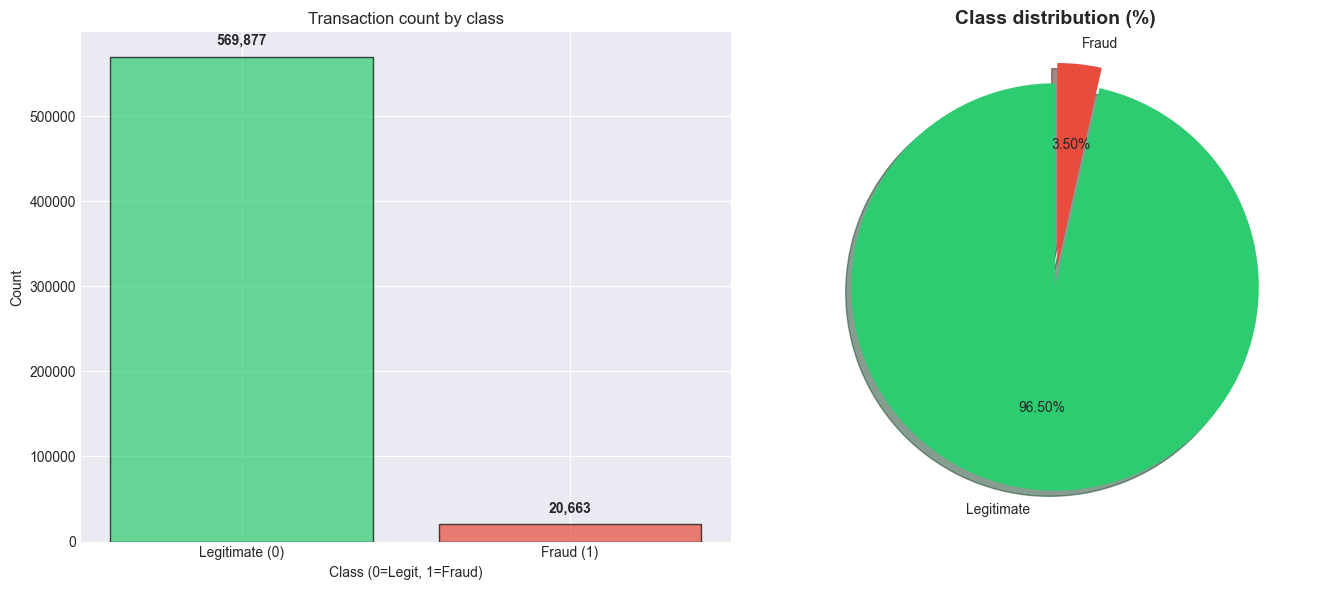

In [7]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
class_counts = train['isFraud'].value_counts()

# Subplot 1: Bar chart showing number of fraud and not fraud trnsactions
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values, 
            color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0].set_title('Transaction count by class')
axes[0].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[0].set_ylabel('Count')

for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10000, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Subplot 2: Pie Chart showing percentage distribution
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)
axes[1].pie(class_counts,
            labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%',
            colors=colors,
            explode=explode,
            shadow=True,
            startangle=90,
            )
axes[1].set_title('Class distribution (%)', fontsize=14, fontweight='bold')


plt.tight_layout()
plt.savefig('../images/class_distribution.png')
plt.show()

# 5. Missing Values Analysis
> Comprehensive analysis of missing data patterns across all features.

In [8]:
# Overall missing value statistics
missing = train.isnull().sum()
missing_pct = round((missing / len(train)) * 100)

missing_df = pd.DataFrame({
    'feature': missing.index,
    'missing_count': missing.values,
    'missing_pct': missing_pct.values
}).sort_values('missing_pct', ascending=False)

total_cells = train.shape[0] * train.shape[1]
total_missing = missing.sum()
overall_missing_pct = (total_missing / total_cells) * 100

print(f"Total cells: {total_cells:,}")
print(f"Missing cells: {total_missing:,}")
print(f"Overall missing rate: {overall_missing_pct:.2f}%")

features_with_missing = (missing > 0).sum()
features_complete = (missing == 0).sum()

print(missing)
print(f"{features_complete} ({features_complete/len(train.columns)*100:.1f}%)")
print(f"{features_with_missing} ({features_with_missing/len(train.columns)*100:.1f}%)")

print("Missing values distribution")
bins = [0, 1, 10, 25, 50, 75, 90, 95, 100]
labels = ['0-1%', '1-10%', '10-25%', '25-50%', '50-75%', '75-90%', '90-95%', '95-100%']

missing_distribution = pd.cut(missing_pct, bins=bins, labels=labels).value_counts().sort_index()

for category, count in missing_distribution.items():
    if count > 0:
        print(f"{category:12s}: {count:3d} features")

Total cells: 256,294,360
Missing cells: 115,523,073
Overall missing rate: 45.07%
TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
id_36             449555
id_37             449555
id_38             449555
DeviceType        449730
DeviceInfo        471874
Length: 434, dtype: int64
20 (4.6%)
414 (95.4%)
Missing values distribution
0-1%        :   1 features
1-10%       :   1 features
10-25%      :  70 features
25-50%      :  38 features
50-75%      :   6 features
75-90%      : 196 features
90-95%      :   3 features
95-100%     :   9 features


In [9]:
# Top features with most missing values
top_missing = missing_df.head(30)

def categorize_feature(col):
    if col.startswith('V'):
        return 'Vesta'
    elif col.startswith('id_'):
        return 'Identity'
    elif col.startswith('M'):
        return 'Categorical_M'
    elif col.startswith('card'):
        return "Card"
    elif 'email' in col.lower():
        return 'Email'
    elif col.startswith('dist'):
        return 'Distance'
    elif col.startswith('addr'):
        return 'Address'
    else:
        return 'Other'
    
for idx, row in top_missing.iterrows():
    category = categorize_feature(row['feature'])
    print(f"{row['feature']:<20} {row['missing_count']:>15,} {row['missing_pct']:>11.2f}% {category:<15}")


id_23                        585,371       99.00% Identity       
id_22                        585,371       99.00% Identity       
id_21                        585,381       99.00% Identity       
id_08                        585,385       99.00% Identity       
id_07                        585,385       99.00% Identity       
id_24                        585,793       99.00% Identity       
id_27                        585,371       99.00% Identity       
id_26                        585,377       99.00% Identity       
id_25                        585,408       99.00% Identity       
dist2                        552,913       94.00% Distance       
D7                           551,623       93.00% Other          
id_18                        545,427       92.00% Identity       
D13                          528,588       90.00% Other          
id_04                        524,216       89.00% Identity       
D12                          525,823       89.00% Other          
id_03     

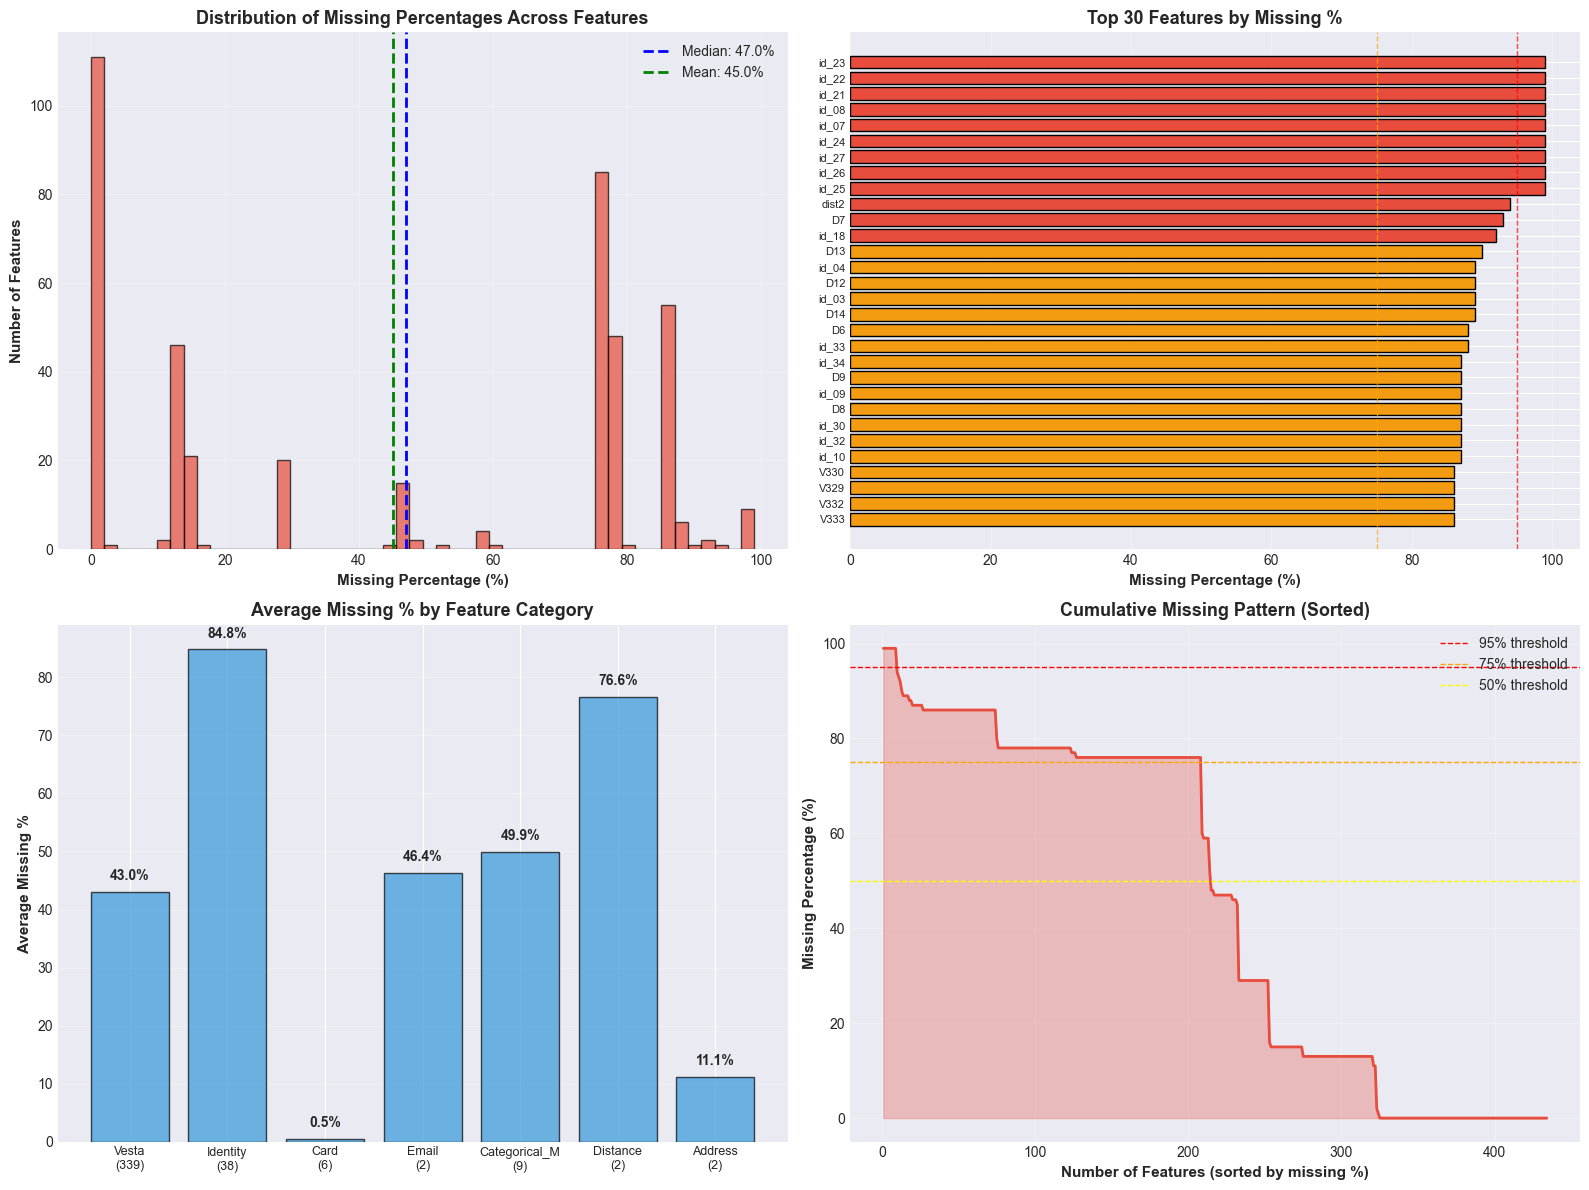

In [10]:
# Visualize missing patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Distribution of missing percentages
axes[0, 0].hist(missing_pct, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(missing_pct.median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {missing_pct.median():.1f}%')
axes[0, 0].axvline(missing_pct.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {missing_pct.mean():.1f}%')
axes[0, 0].set_xlabel('Missing Percentage (%)', fontweight='bold', fontsize=11)
axes[0, 0].set_ylabel('Number of Features', fontweight='bold', fontsize=11)
axes[0, 0].set_title('Distribution of Missing Percentages Across Features', fontweight='bold', fontsize=13)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Top 30 most missing features (horizontal bar)
top_30 = missing_df.head(30)
colors = ['#e74c3c' if x > 90 else '#f39c12' if x > 75 else '#f1c40f' for x in top_30['missing_pct']]
axes[0, 1].barh(range(len(top_30)), top_30['missing_pct'], color=colors, edgecolor='black')
axes[0, 1].set_yticks(range(len(top_30)))
axes[0, 1].set_yticklabels(top_30['feature'], fontsize=8)
axes[0, 1].set_xlabel('Missing Percentage (%)', fontweight='bold', fontsize=11)
axes[0, 1].set_title('Top 30 Features by Missing %', fontweight='bold', fontsize=13)
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Add vertical lines for thresholds
axes[0, 1].axvline(95, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[0, 1].axvline(75, color='orange', linestyle='--', linewidth=1, alpha=0.7)

# Plot 3: Missing by category
category_missing = []
category_names = []

for category in ['Vesta', 'Identity', 'Card', 'Email', 'Categorical_M', 'Distance', 'Address']:
    cols = [col for col in train.columns if categorize_feature(col) == category]
    if cols:
        avg_missing = train[cols].isnull().sum().sum() / (len(train) * len(cols)) * 100
        category_missing.append(avg_missing)
        category_names.append(f"{category}\n({len(cols)})")

axes[1, 0].bar(range(len(category_missing)), category_missing, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(len(category_names)))
axes[1, 0].set_xticklabels(category_names, fontsize=9)
axes[1, 0].set_ylabel('Average Missing %', fontweight='bold', fontsize=11)
axes[1, 0].set_title('Average Missing % by Feature Category', fontweight='bold', fontsize=13)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(category_missing):
    axes[1, 0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 4: Cumulative missing features
missing_sorted = missing_df.sort_values('missing_pct', ascending=False)
cumulative_features = range(1, len(missing_sorted) + 1)
axes[1, 1].plot(cumulative_features, missing_sorted['missing_pct'].values, color='#e74c3c', linewidth=2)
axes[1, 1].fill_between(cumulative_features, missing_sorted['missing_pct'].values, alpha=0.3, color='#e74c3c')
axes[1, 1].axhline(95, color='red', linestyle='--', linewidth=1, label='95% threshold')
axes[1, 1].axhline(75, color='orange', linestyle='--', linewidth=1, label='75% threshold')
axes[1, 1].axhline(50, color='yellow', linestyle='--', linewidth=1, label='50% threshold')
axes[1, 1].set_xlabel('Number of Features (sorted by missing %)', fontweight='bold', fontsize=11)
axes[1, 1].set_ylabel('Missing Percentage (%)', fontweight='bold', fontsize=11)
axes[1, 1].set_title('Cumulative Missing Pattern (Sorted)', fontweight='bold', fontsize=13)
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/missing_distribution.png')
plt.show()


In [11]:
# Does missing data correlate with Fraud
features_to_test = missing_df[
    (missing_df['missing_pct'] > 10) &
    (missing_df['missing_pct'] < 90)
]['feature'].tolist()

fraud_correlations = []

for col in features_to_test:
    if col =='isFraud':
        continue

    # Fraud rate when value is missing
    fraud_when_missing = train[train[col].isna()]['isFraud'].mean() * 100

    # Fraud rate when value is present
    fraud_when_present = train[train[col].notna()]['isFraud'].mean() * 100

    # Difference
    difference = fraud_when_missing - fraud_when_present

    fraud_correlations.append({
        'feature': col,
        'fraud_rate_missing': fraud_when_missing,
        'fraud_rate_present': fraud_when_present,
        'difference': difference,
        'missing_pct': missing_df[missing_df['feature'] == col]['missing_pct'].values[0]
    })

# Convert to DataFrame and sort by difference
fraud_corr_df = pd.DataFrame(fraud_correlations).sort_values('difference', key=abs, ascending=False)

for idx, row in fraud_corr_df.head(15).iterrows():
    diff_str = f"{row['difference']:+.2f}%"
    print(f"{row['feature']:<20} {row['fraud_rate_missing']:>14.2f}% {row['fraud_rate_present']:>14.2f}% {diff_str:>12} {row['missing_pct']:>9.1f}%")


significant_diff = fraud_corr_df[fraud_corr_df['difference'].abs() > 0.1]

if len(significant_diff) > 0:
    print('Missing values are informative')
else:
    print('Missing appears to be random')



addr2                         11.78%           2.46%       +9.32%      11.0%
addr1                         11.78%           2.46%       +9.32%      11.0%
D12                            2.48%          11.74%       -9.26%      89.0%
D14                            2.55%          11.60%       -9.05%      89.0%
id_04                          2.59%          10.72%       -8.14%      89.0%
id_03                          2.59%          10.72%       -8.14%      89.0%
D6                             2.50%          10.55%       -8.04%      88.0%
D8                             2.49%          10.45%       -7.96%      87.0%
id_10                          2.49%          10.45%       -7.96%      87.0%
id_09                          2.49%          10.45%       -7.96%      87.0%
D9                             2.49%          10.45%       -7.96%      87.0%
id_13                          2.17%           8.32%       -6.14%      78.0%
R_emaildomain                  2.08%           8.18%       -6.10%      77.0%

In [12]:
# Handling missing values
handling_plan = {
    'keep_complete': [],
    'keep_low_missing': [], # 0-25% missing
    'keep_with_flag': [], # 25-75% missing, create is_missing flag
    'keep_high_missing': [], #75-95% missing, keep if informative
    'consider_dropping': [] #>95% missing
}

# 6. Transaction Feature 
A deep dive into the core transactional features.
In this section we will analyse the following features:
- `TransactionAmt` - Transaction amount (USD)
- `TransactionDT` - Time delta for reference (seconds)
- `ProductCD` - Product code (W, C, H, S, R)
- `card1-card6` - Payment card information
- `addr1-addr2` - Address information
- `dist1-dist2` - Distance measurements

Our main goal for this section id to discover fraud patterns in transaction features.

In [13]:
# Statistics by fraud status
print(train['TransactionAmt'].describe())
fraud_stats = train.groupby('isFraud')['TransactionAmt'].describe()
fraud_stats.index = ['Legitimate', 'Fraud']
display(fraud_stats)

# Calculate differences
mean_diff = fraud_stats.loc['Fraud', 'mean'] - fraud_stats.loc['Legitimate', 'mean']
median_diff  = fraud_stats.loc['Fraud', '50%'] - fraud_stats.loc['Legitimate', '50%']

print(f"Mean difference :${mean_diff:.2f}")
print(f"Median difference: ${median_diff:.2f}")

if mean_diff > 0:
    print('Fraudelent transactions are higher in amount per transaction.')
elif mean_diff < 0:
    print('Fraudelent transactions are lower in amount per transaction.')
else:
    print('No clear difference.')

# Outliers
print(f"Minimum amount: ${train['TransactionAmt'].min():.2f}")
print(f"Maximum amount: ${train['TransactionAmt'].max():,.2f}")
print(f"Amounts > $1000: {(train['TransactionAmt'] > 1000).sum():,} ({(train['TransactionAmt'] > 1000).mean() * 100:.2f}%)")
print(f"Amounts < $10: {(train['TransactionAmt'] < 10).sum():,} ({(train['TransactionAmt'] < 10).mean()*100:.2f}%)")

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


,count,mean,std,min,25%,50%,75%,max
Legitimate,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
Fraud,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


Mean difference :$14.73
Median difference: $6.50
Fraudelent transactions are higher in amount per transaction.
Minimum amount: $0.25
Maximum amount: $31,937.39
Amounts > $1000: 7,267 (1.23%)
Amounts < $10: 6,795 (1.15%)


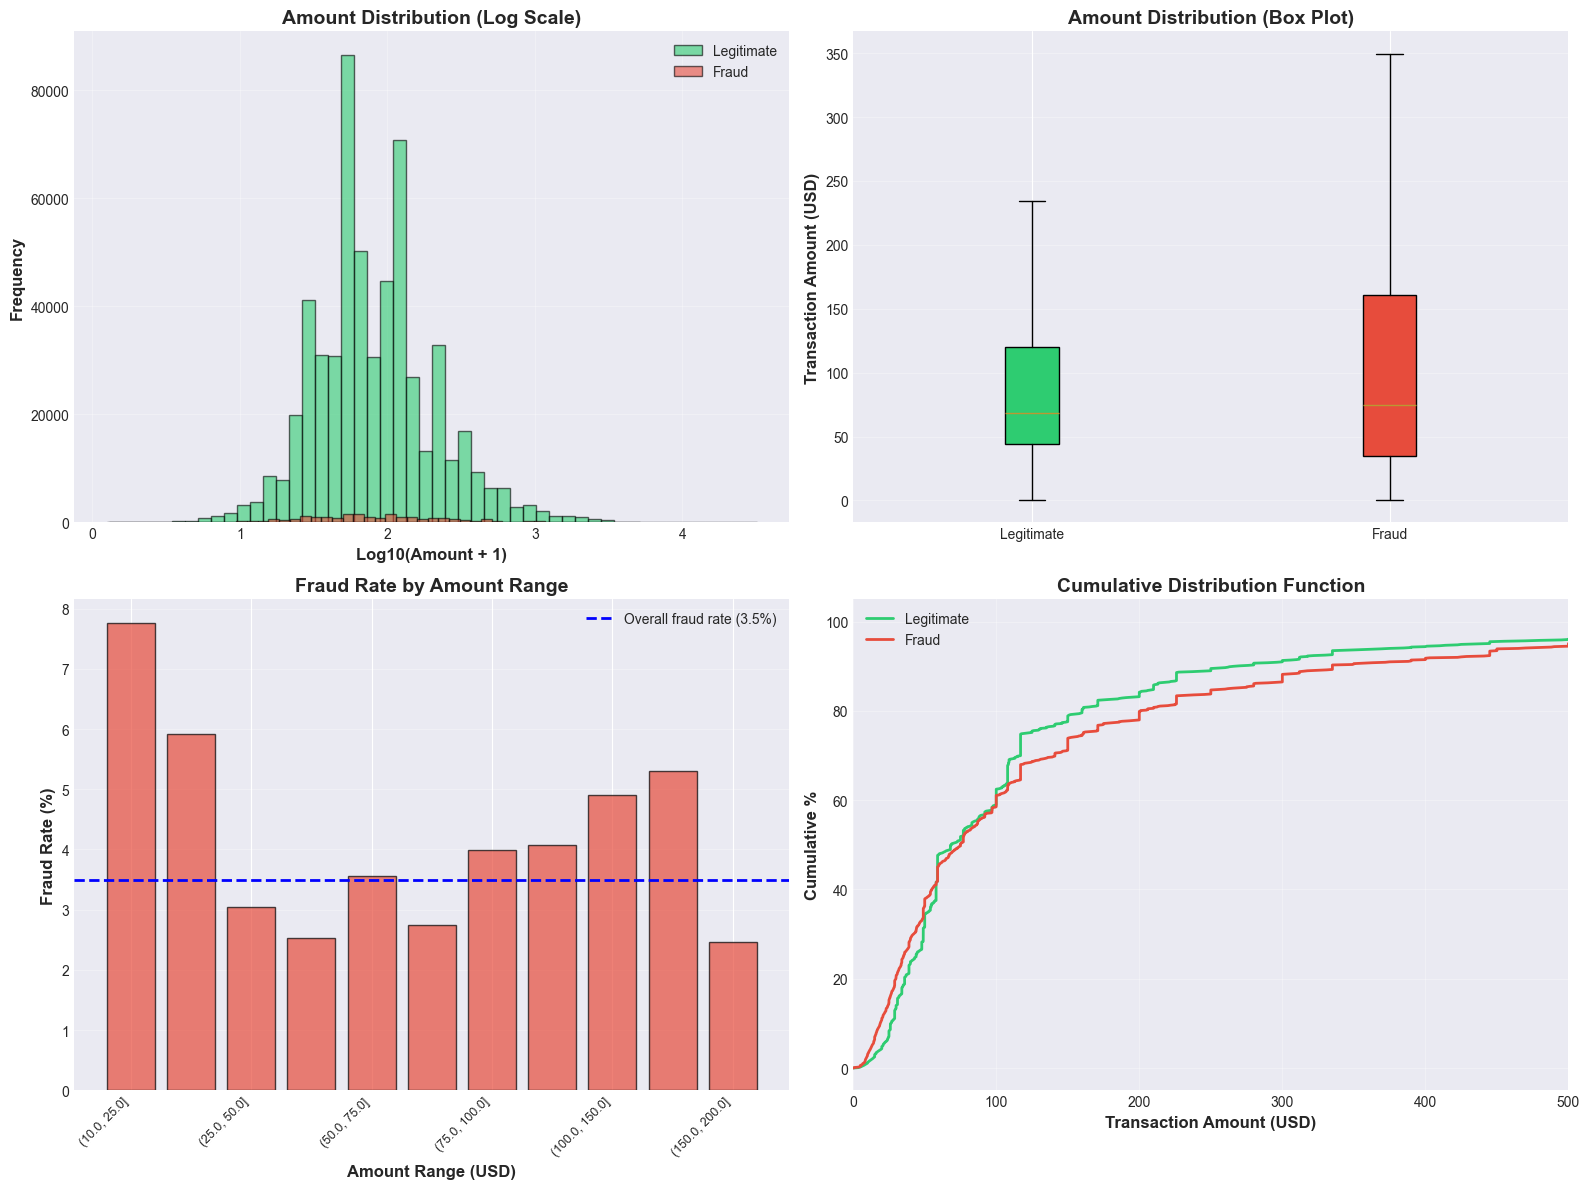

In [14]:
# Amount distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Distribution comparison(using log scale)
for fraud_flag in [0, 1]:
    label = 'Fraud' if fraud_flag == 1 else 'Legitimate'
    color = '#e74c3c' if fraud_flag == 1 else '#2ecc71'
    data = train[train['isFraud'] == fraud_flag]['TransactionAmt']

    axes[0, 0].hist(np.log10(data + 1), bins=50, alpha=0.6, label=label, color=color, edgecolor='black')

axes[0, 0].set_xlabel('Log10(Amount + 1)', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontweight='bold', fontsize=12)
axes[0, 0].set_title('Amount Distribution (Log Scale)', fontweight='bold', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Box plot for comparison
box_data = [
    train[train['isFraud'] == 0]['TransactionAmt'],
    train[train['isFraud'] == 1]['TransactionAmt']
]

bp = axes[0, 1].boxplot(box_data, labels=['Legitimate', 'Fraud'], patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[0, 1].set_ylabel('Transaction Amount (USD)', fontweight='bold', fontsize=12)
axes[0, 1].set_title('Amount Distribution (Box Plot)', fontweight='bold', fontsize=14)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Fraud rate by amount bins
amount_bins = [0, 10, 25, 50, 75, 100, 150, 200, 300, 500, 1000, np.inf]
train['amount_bin'] = pd.cut(train['TransactionAmt'], bins=amount_bins)
fraud_by_amount = train.groupby('amount_bin', observed=True).agg({'isFraud': ['mean', 'count']}).reset_index()
fraud_by_amount.columns = ['amount_bin', 'fraud_rate', 'count']
fraud_by_amount['fraud_rate_pct'] = fraud_by_amount['fraud_rate'] * 100

# Filter bins with sufficient data
fraud_by_amount_filtered = fraud_by_amount[fraud_by_amount['count'] > 100]

x_labels = [str(b) for b in fraud_by_amount_filtered['amount_bin']]
axes[1, 0].bar(range(len(fraud_by_amount_filtered)), fraud_by_amount_filtered['fraud_rate_pct'], color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 0].axhline(y=3.5, color='blue', linestyle='--', linewidth=2, label='Overall fraud rate (3.5%)')
axes[1, 0].set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
axes[1, 0].set_ylabel('Fraud Rate (%)', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Amount Range (USD)', fontweight='bold', fontsize=12)
axes[1, 0].set_title('Fraud Rate by Amount Range', fontweight='bold', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Cumulative Distribution
for fraud_flag in [0, 1]:
    label = 'Fraud' if fraud_flag == 1 else 'Legitimate'
    color = '#e74c3c' if fraud_flag == 1 else '#2ecc71'
    data = train[train['isFraud'] == fraud_flag]['TransactionAmt'].sort_values()
    cumulative = np.arange(1, len(data) + 1) / len(data) * 100

    # Sample for plotting to avoid too many plotting points
    sample_idx = np.linspace(0, len(data) - 1, 1000, dtype=int)
    axes[1, 1].plot(data.iloc[sample_idx], cumulative[sample_idx], label=label, color=color, linewidth=2)

axes[1, 1].set_xlabel('Transaction Amount (USD)', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Cumulative %', fontweight='bold', fontsize=12)
axes[1, 1].set_title('Cumulative Distribution Function', fontweight='bold', fontsize=14)
axes[1, 1].set_xlim(0, 500)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/transaction_amt_distribution.png')
plt.show()


In [15]:
# Feature engineering and analysis
# Convert TransactionDT to hours and Days
train['transaction_hour'] = train['TransactionDT'] // 3600 % 24
train['transaction_day'] = train['TransactionDT'] // (3600 * 24)
train['transaction_day_of_week'] = (train['transaction_day'] % 7)

# Time stats
total_number_of_days = train['transaction_day'].max()
transactions_per_day = len(train) / total_number_of_days
transactions_per_hour = len(train) / (total_number_of_days * 24)
print(f"Total number of days observed is {total_number_of_days}")
print(f"An average of {transactions_per_day:.0f} transactions per day and {transactions_per_hour:.0f} transactions per hour were observed")

Total number of days observed is 182
An average of 3245 transactions per day and 135 transactions per hour were observed


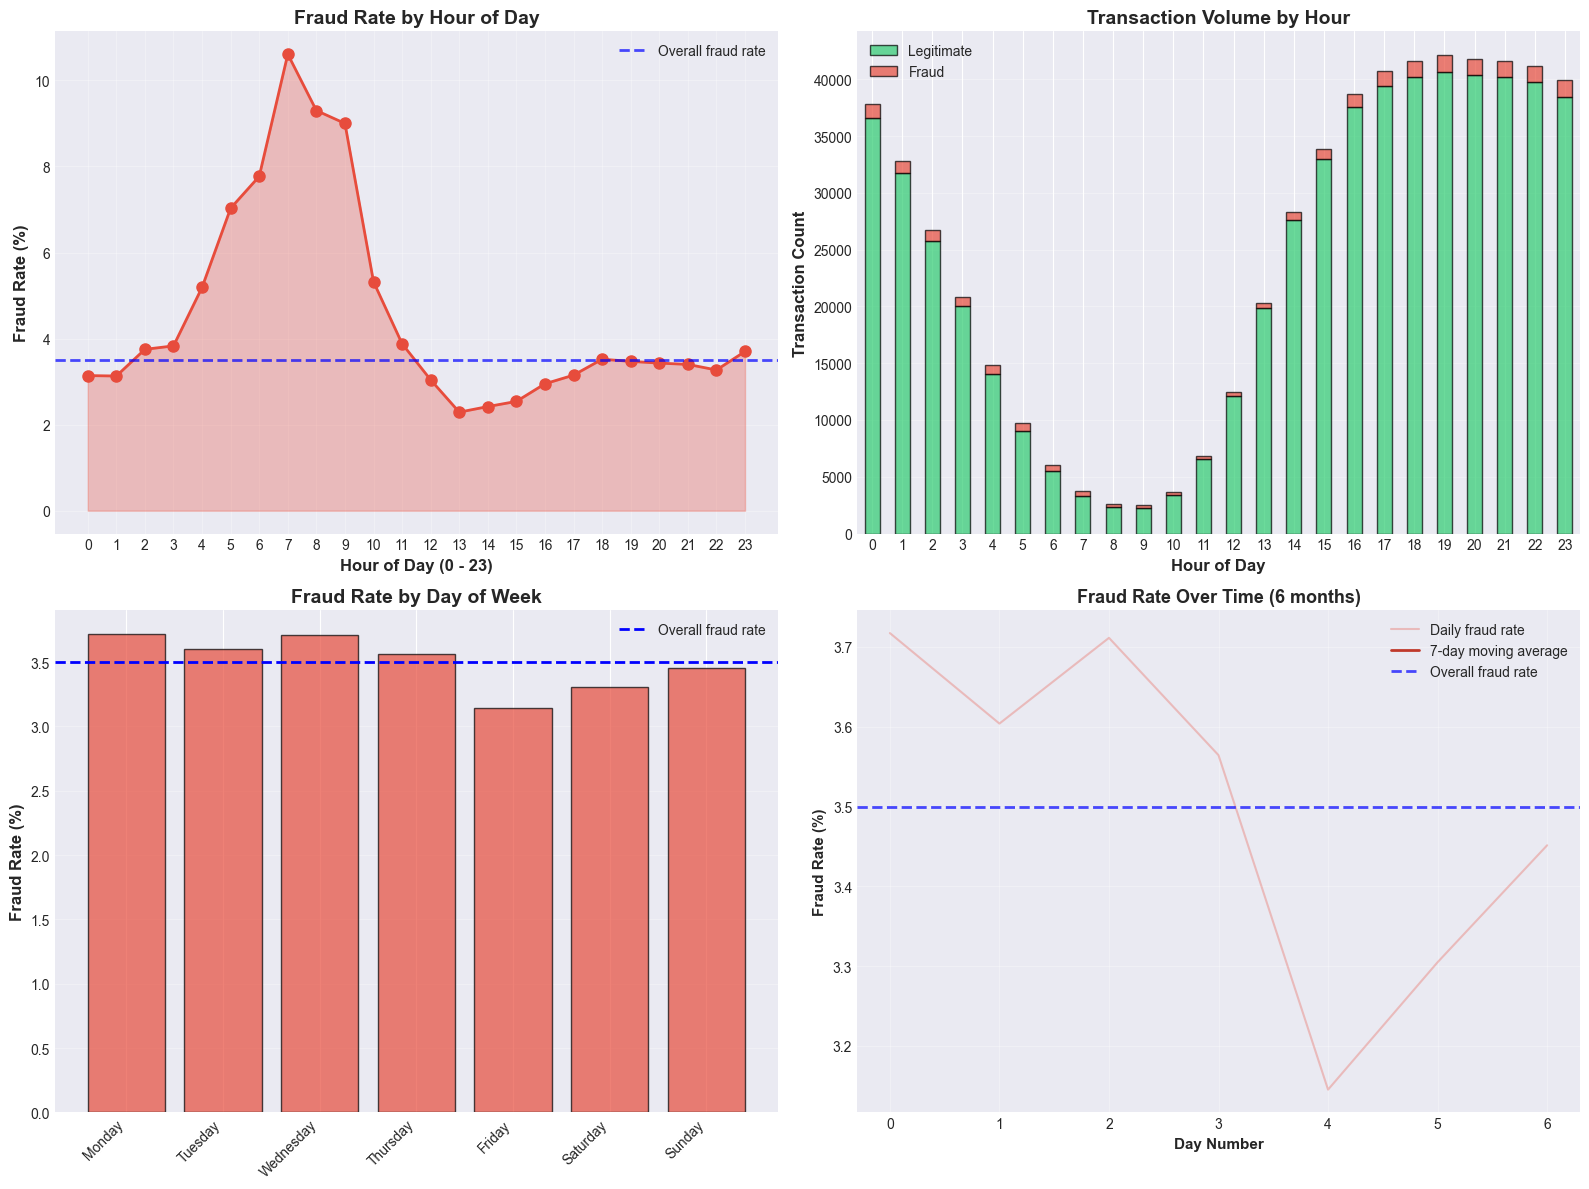

In [16]:
# Visualize Time Related Fraud Patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Fraud rate by hour of day
fraud_by_hour = train.groupby('transaction_hour').agg({'isFraud': ['mean', 'count']}).reset_index()
fraud_by_hour.columns = ['hour', 'fraud_rate', 'count']
fraud_by_hour['fraud_rate_pct'] = round(fraud_by_hour['fraud_rate'] * 100, 2)

axes[0, 0].plot(fraud_by_hour['hour'], fraud_by_hour['fraud_rate_pct'], marker='o', linewidth=2, markersize=8, color='#e74c3c')
axes[0, 0].axhline(y=3.5, color='blue', linestyle='--', linewidth=2, label='Overall fraud rate', alpha=0.7)
axes[0, 0].fill_between(fraud_by_hour['hour'], fraud_by_hour['fraud_rate_pct'], alpha=0.3, color='#e74c3c')
axes[0, 0].set_xlabel('Hour of Day (0 - 23)', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Fraud Rate (%)', fontweight='bold', fontsize=12)
axes[0, 0].set_title('Fraud Rate by Hour of Day', fontweight='bold', fontsize=14)
axes[0, 0].set_xticks(range(0, 24))
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Transaction volume by hour
volume_by_hour = train.groupby(['transaction_hour', 'isFraud']).size().unstack()
volume_by_hour.plot(kind='bar', stacked=True, ax=axes[0, 1], color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Hour of Day', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Transaction Count', fontweight='bold', fontsize=12)
axes[0, 1].set_title('Transaction Volume by Hour', fontweight='bold', fontsize=14)
axes[0, 1].legend(['Legitimate', 'Fraud'])
axes[0, 1].set_xticklabels(range(24), rotation=0)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Fraud rate by day of the week
fraud_by_weekday = train.groupby('transaction_day_of_week').agg({'isFraud': ['mean', 'count']}).reset_index()
fraud_by_weekday.columns = ['day', 'fraud_rate', 'count']
fraud_by_weekday['fraud_rate_pct'] = fraud_by_weekday['fraud_rate'] * 100

name_of_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[1, 0].bar(range(7), fraud_by_weekday['fraud_rate_pct'], color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 0].axhline(y=3.5, color='blue', linestyle='--', linewidth=2, label='Overall fraud rate')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(name_of_days, rotation=45, ha='right')
axes[1, 0].set_ylabel('Fraud Rate (%)', fontweight='bold', fontsize=12)
axes[1, 0].set_title('Fraud Rate by Day of Week', fontweight='bold', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Fraud over time (trend)
fraud_by_day = train.groupby('transaction_day_of_week').agg({
    'isFraud': ['mean', 'count']
}).reset_index()
fraud_by_day.columns = ['day', 'fraud_rate', 'count']
fraud_by_day['fraud_rate_pct'] = fraud_by_day['fraud_rate'] * 100

# Rolling average
fraud_by_day['fraud_rate_ma7'] = fraud_by_day['fraud_rate_pct'].rolling(7, center=True).mean()

axes[1, 1].plot(fraud_by_day['day'], fraud_by_day['fraud_rate_pct'], 
                alpha=0.3, color='#e74c3c', label='Daily fraud rate')
axes[1, 1].plot(fraud_by_day['day'], fraud_by_day['fraud_rate_ma7'], 
                linewidth=2, color='#c0392b', label='7-day moving average')
axes[1, 1].axhline(y=3.5, color='blue', linestyle='--', linewidth=2, 
                   label='Overall fraud rate', alpha=0.7)
axes[1, 1].set_xlabel('Day Number', fontweight='bold', fontsize=11)
axes[1, 1].set_ylabel('Fraud Rate (%)', fontweight='bold', fontsize=11)
axes[1, 1].set_title('Fraud Rate Over Time (6 months)', fontweight='bold', fontsize=13)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('../images/fraud_time_distribution.png')
plt.show()


In [17]:
# Product and Card Analysis
# Product Analysis
product_analysis = train.groupby('ProductCD').agg({
    'isFraud': ['count', 'sum', 'mean'],
    'TransactionAmt': 'mean'
}).round(4)
product_analysis.columns = ['count', 'fraud_count', 'fraud_rate', 'avg_amount']
product_analysis['fraud_rate_pct'] = product_analysis['fraud_rate'] * 100
product_analysis = product_analysis.sort_values('fraud_rate', ascending=False)

print(product_analysis)

# Card Analysis
# Type of card
if 'card4' in train.columns:
    card4_analysis = train.groupby('card4').agg({'isFraud': ['count', 'sum', 'mean']}).round(4)
    card4_analysis.columns = ['count', 'fraud_count', 'fraud_rate']
    card4_analysis['fraud_rate_pct'] = card4_analysis['fraud_rate'] * 100
    card4_analysis = card4_analysis.sort_values('fraud_rate', ascending=False)
    print(card4_analysis)

# Card category
if 'card6' in train.columns:
    card6_analysis = train.groupby('card6').agg({'isFraud': ['count', 'sum', 'mean']}).round(4)
    card6_analysis.columns = ['count', 'fraud_count', 'fraud_rate']
    card6_analysis['fraud_rate_pct'] = card6_analysis['fraud_rate'] * 100
    card6_analysis = card6_analysis.sort_values('fraud_rate', ascending=False)
    print(card6_analysis)

            count  fraud_count  fraud_rate  avg_amount  fraud_rate_pct
ProductCD                                                             
C           68519         8008      0.1169     42.8724           11.69
S           11628          686      0.0590     60.2695            5.90
H           33024         1574      0.0477     73.1701            4.77
R           37699         1426      0.0378    168.3062            3.78
W          439670         8969      0.0204    153.1586            2.04
                   count  fraud_count  fraud_rate  fraud_rate_pct
card4                                                            
discover            6651          514      0.0773            7.73
visa              384767        13373      0.0348            3.48
mastercard        189217         6496      0.0343            3.43
american express    8328          239      0.0287            2.87
                  count  fraud_count  fraud_rate  fraud_rate_pct
card6                                     

# 7.Baseline Model

In [18]:
# Dropping columns we don't need
columns_to_drop = ['TransactionID', 'isFraud', 'amount_bin', 'transaction_hour', 'transaction_day',
       'transaction_day_of_week']

display(train.columns)

X = train.drop(columns=columns_to_drop)
y = train['isFraud']

print(train.shape)
print(X.shape)
print(y.shape)

# Encode categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()

    #Handle missing values by filling with 'missing'
    X[col] = X[col].fillna('missing')
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Numeric cols
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Fill missing with -999
X[numeric_cols] = X[numeric_cols].fillna(-999)

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo',
       'amount_bin', 'transaction_hour', 'transaction_day',
       'transaction_day_of_week'],
      dtype='object', length=438)

(590540, 438)
(590540, 432)
(590540,)


In [19]:
# Create train split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight.round(2))

# Model parameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'tree_method': 'hist',
    'n_jobs': -1,
    'early_stopping_rounds':10
}

# Create and train an XGBoos model
start_time = time.time()
model = xgb.XGBClassifier(**params)
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=10
)

training_time = time.time() - start_time
print(f"Total training time was {training_time}s")
print(f"Best iteration: {model.best_iteration}")
print(f"Best score: {model.best_score:.4f}")


27.77
[0]	validation_0-auc:0.84847	validation_1-auc:0.84850
[10]	validation_0-auc:0.88116	validation_1-auc:0.87929
[20]	validation_0-auc:0.89406	validation_1-auc:0.89119
[30]	validation_0-auc:0.90346	validation_1-auc:0.89897
[40]	validation_0-auc:0.91073	validation_1-auc:0.90515
[50]	validation_0-auc:0.91762	validation_1-auc:0.91103
[60]	validation_0-auc:0.92328	validation_1-auc:0.91583
[70]	validation_0-auc:0.92806	validation_1-auc:0.92014
[80]	validation_0-auc:0.93186	validation_1-auc:0.92292
[90]	validation_0-auc:0.93496	validation_1-auc:0.92519
[99]	validation_0-auc:0.93917	validation_1-auc:0.92858
Total training time was 240.28522086143494s
Best iteration: 99
Best score: 0.9286


In [28]:
# Model Evaluation
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"True negatives: {tn} transactions were correctly identified as legitimate transactions")
print(f"True positives: {tp} transactions were correctly flagged as fraud")
print(f"False positives: {fp} transactions were falsely flagged as fraud")
print(f"False negatives: {fn} transactions were falsely identified as legitimate transactions")

print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud'], digits=4))

ROC-AUC Score: 0.9286
True negatives: 102277 transactions were correctly identified as legitimate transactions
True positives: 3404 transactions were correctly flagged as fraud
False positives: 11589 transactions were falsely flagged as fraud
False negatives: 838 transactions were flasely identified as legitimate transactions
              precision    recall  f1-score   support

  Legitimate     0.9919    0.8982    0.9427    113866
       Fraud     0.2270    0.8025    0.3539      4242

    accuracy                         0.8948    118108
   macro avg     0.6095    0.8503    0.6483    118108
weighted avg     0.9644    0.8948    0.9216    118108



In [34]:
# Feature importance
feature_importance = model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(f"{'Rank':<6} {'Feature':<25} {'Importance':<12} {'Category':<15}")

def categorize_feature(col):
    if col.startswith('V'):
        return 'Vesta'
    elif col.startswith('id_') or 'Device' in col:
        return 'Identity'
    elif col.startswith('M'):
        return 'Categorical_M'
    elif col.startswith('card'):
        return 'Card'
    elif 'email' in col.lower():
        return 'Email'
    elif col.startswith('dist'):
        return 'Distance'
    elif col.startswith('addr'):
        return 'Address'
    elif col in ['TransactionAmt', 'TransactionDT', 'ProductCD']:
        return 'Transaction'
    else:
        return 'Other'


for rank, (idx, row) in enumerate(importance_df.head(10).iterrows(), 1):
    category = categorize_feature(row['feature'])
    print(f"{rank:<6} {row['feature']:<25} {row['importance']:12.6f} {category:<15}")

importance_df['category'] = importance_df['feature'].apply(categorize_feature)
category_importance = importance_df.groupby('category')['importance'].agg(['sum', 'mean', 'count'])
category_importance = category_importance.sort_values('sum', ascending=False)

print(f"{'Category':<15} {'Total Imp.':<12} {'Avg Imp.':<12} {'Count':<8}")
print("─" * 50)
for category, row in category_importance.iterrows():
    print(f"{category:<15} {row['sum']:<12.4f} {row['mean']:<12.6f} {int(row['count']):<8}")

print("\n💡 Key Insights:")
top_category = category_importance.index[0]
print(f"   → {top_category} features are most important overall")
print(f"   → Top single feature: {importance_df.iloc[0]['feature']}")
print(f"   → Transaction core features (Amount, Time) likely in top 10")
    

Rank   Feature                   Importance   Category       
1      V258                          0.129635 Vesta          
2      V70                           0.087106 Vesta          
3      V91                           0.073775 Vesta          
4      V201                          0.066205 Vesta          
5      V294                          0.035316 Vesta          
6      C8                            0.026700 Other          
7      V322                          0.024841 Vesta          
8      V312                          0.014931 Vesta          
9      C14                           0.014677 Other          
10     V283                          0.012764 Vesta          
Category        Total Imp.   Avg Imp.     Count   
──────────────────────────────────────────────────
Vesta           0.7834       0.002311     339     
Other           0.1153       0.003976     29      
Identity        0.0363       0.000908     40      
Categorical_M   0.0265       0.002941     9       
Card        

VISUALIZING MODEL PERFORMANCE


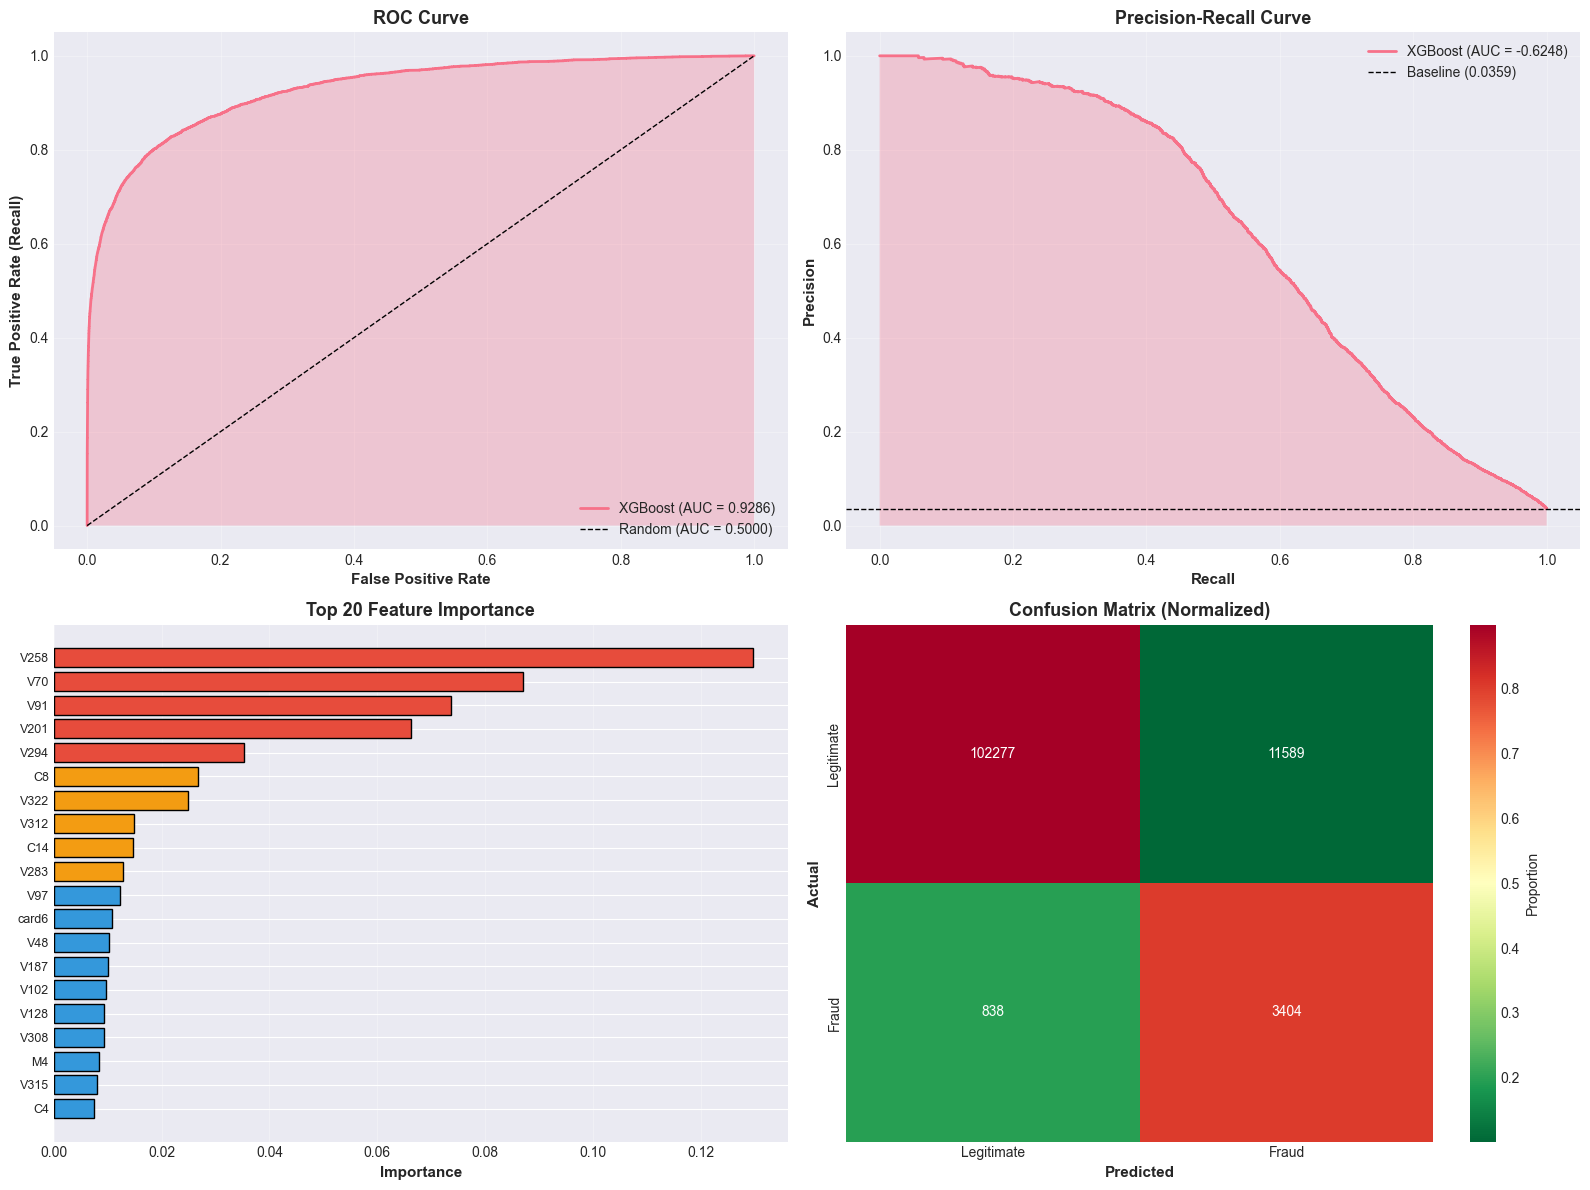


✅ Visualizations created!


In [38]:
# Visualize results
print("=" * 80)
print("VISUALIZING MODEL PERFORMANCE")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)

axes[0, 0].plot(fpr, tpr, linewidth=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5000)')
axes[0, 0].fill_between(fpr, tpr, alpha=0.3)
axes[0, 0].set_xlabel('False Positive Rate', fontweight='bold', fontsize=11)
axes[0, 0].set_ylabel('True Positive Rate (Recall)', fontweight='bold', fontsize=11)
axes[0, 0].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Precision-Recall Curve
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
pr_auc = np.trapezoid(precision_curve, recall_curve)

axes[0, 1].plot(recall_curve, precision_curve, linewidth=2, 
                label=f'XGBoost (AUC = {pr_auc:.4f})')
axes[0, 1].axhline(y=y_test.mean(), color='k', linestyle='--', linewidth=1,
                   label=f'Baseline ({y_test.mean():.4f})')
axes[0, 1].fill_between(recall_curve, precision_curve, alpha=0.3)
axes[0, 1].set_xlabel('Recall', fontweight='bold', fontsize=11)
axes[0, 1].set_ylabel('Precision', fontweight='bold', fontsize=11)
axes[0, 1].set_title('Precision-Recall Curve', fontweight='bold', fontsize=13)
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 20)
top_20_features = importance_df.head(20)
colors = ['#e74c3c' if i < 5 else '#f39c12' if i < 10 else '#3498db' 
          for i in range(len(top_20_features))]

axes[1, 0].barh(range(len(top_20_features)), top_20_features['importance'], 
                color=colors, edgecolor='black')
axes[1, 0].set_yticks(range(len(top_20_features)))
axes[1, 0].set_yticklabels(top_20_features['feature'], fontsize=9)
axes[1, 0].set_xlabel('Importance', fontweight='bold', fontsize=11)
axes[1, 0].set_title('Top 20 Feature Importance', fontweight='bold', fontsize=13)
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3, axis='x')

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
import seaborn as sns
sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='RdYlGn_r',
xticklabels=['Legitimate', 'Fraud'],
yticklabels=['Legitimate', 'Fraud'],
cbar_kws={'label': 'Proportion'},
ax=axes[1, 1])
axes[1, 1].set_ylabel('Actual', fontweight='bold', fontsize=11)
axes[1, 1].set_xlabel('Predicted', fontweight='bold', fontsize=11)
axes[1, 1].set_title('Confusion Matrix (Normalized)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
print("\n✅ Visualizations created!")
